<a href="https://colab.research.google.com/github/BuiTranNgocKhai/part_3_email_detechtion/blob/khai_part_3/khai_part_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part 1: Clean Data

Saving spam.csv to spam (5).csv
Đã đoán encoding: Windows-1252
Số lượng ham/spam:
label
ham     4825
spam     747
Name: count, dtype: int64


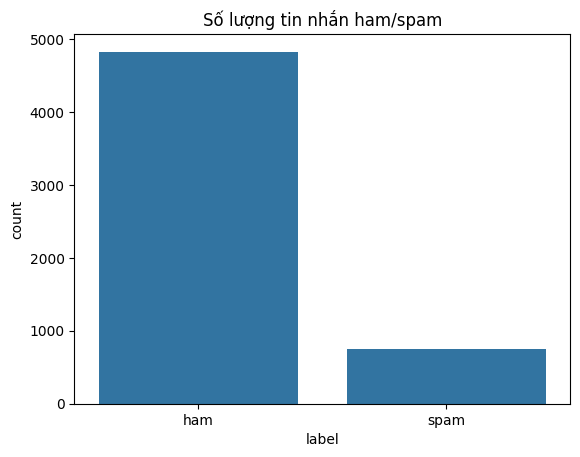

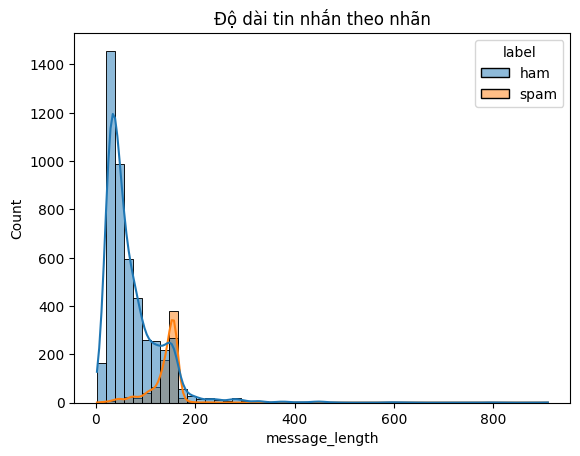

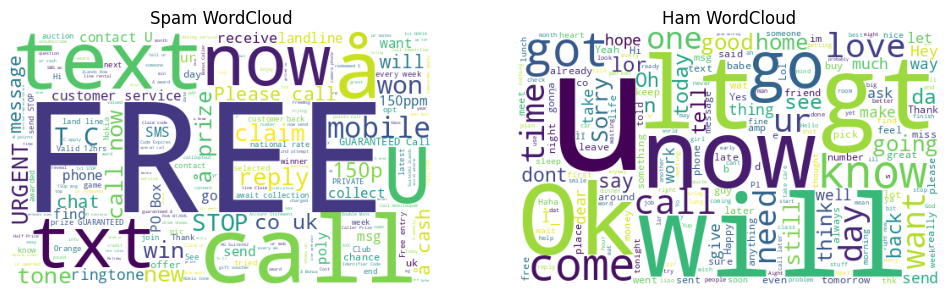

  label                                      clean_message
0   ham  go jurong point crazy available bugis n great ...
1   ham                            ok lar joking wif u oni
2  spam  free entry wkly comp win fa cup final tkts st ...
3   ham                u dun say early hor u c already say
4   ham        nah dont think goes usf lives around though


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Đoạn 1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import chardet
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
from google.colab import files
import io

# 🧾 BƯỚC 1: Upload file từ máy tính
uploaded = files.upload()

# Lấy tên file vừa upload
file_name = next(iter(uploaded))

# Tự động phát hiện encoding
with io.BytesIO(uploaded[file_name]) as f:
    result = chardet.detect(f.read(10000))
    encoding = result['encoding']
    print(f"Đã đoán encoding: {encoding}")

# Đọc dữ liệu
df = pd.read_csv(io.BytesIO(uploaded[file_name]), encoding=encoding)
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# 📊 BƯỚC 2: Khám phá dữ liệu (EDA)
print("Số lượng ham/spam:")
print(df['label'].value_counts())

sns.countplot(data=df, x='label')
plt.title("Số lượng tin nhắn ham/spam")
plt.show()

df['message_length'] = df['message'].apply(len)
sns.histplot(data=df, x='message_length', hue='label', bins=50, kde=True)
plt.title("Độ dài tin nhắn theo nhãn")
plt.show()

# ☁️ BƯỚC 3: Tạo WordCloud
spam_text = ' '.join(df[df['label'] == 'spam']['message'])
ham_text = ' '.join(df[df['label'] == 'ham']['message'])

plt.figure(figsize=(12,6))

plt.subplot(1, 2, 1)
plt.imshow(WordCloud(width=500, height=300, background_color='white').generate(spam_text))
plt.axis("off")
plt.title("Spam WordCloud")

plt.subplot(1, 2, 2)
plt.imshow(WordCloud(width=500, height=300, background_color='white').generate(ham_text))
plt.axis("off")
plt.title("Ham WordCloud")
plt.show()

# 🧹 BƯỚC 4: Làm sạch tin nhắn
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_message(msg):
    msg = msg.lower()
    msg = re.sub(r'\d+', '', msg)
    msg = re.sub(r'[^\w\s]', '', msg)
    words = msg.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

df['clean_message'] = df['message'].apply(clean_message)
df_output = df[['label', 'clean_message']]
print(df_output.head())


Part 2: Convert data to 0/1

In [ ]:
# Đoạn 2
def vectorize_and_split(clean_df):
    from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
    from sklearn.model_selection import train_test_split

    # Vector hóa văn bản
    count_vectorizer = CountVectorizer()
    X_counts = count_vectorizer.fit_transform(clean_df['clean_message'].astype('U'))

    tfidf_vectorizer = TfidfVectorizer()
    X_tfidf = tfidf_vectorizer.fit_transform(clean_df['clean_message'].astype('U'))

    y = clean_df['label'].values

    # Chia tập dữ liệu
    X_train_counts, X_test_counts, y_train_counts, y_test_counts = train_test_split(
        X_counts, y, test_size=0.2, random_state=42)

    X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
        X_tfidf, y, test_size=0.2, random_state=42)

    return {
        'count': (X_train_counts, X_test_counts, y_train_counts, y_test_counts, count_vectorizer),
        'tfidf': (X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf, tfidf_vectorizer)
    }

Part 3: Apply module

Lấy dữ liệu train/test

In [ ]:
#Đoạn 3
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, BaggingClassifier,
    ExtraTreesClassifier, GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib

from xgboost import XGBClassifier

data = vectorize_and_split(clean_df)['tfidf']
X_train, X_test, y_train, y_test, tfidf_vectorizer = data


NameError: name 'clean_df' is not defined

Model Naive Bayes

In [ ]:
nb_clf = BernoulliNB()
nb_clf.fit(X_train, y_train)
y_pred_nb = nb_clf.predict(X_test)
# Tính các chỉ số đánh giá
acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, pos_label='spam')
rec_nb = recall_score(y_test, y_pred_nb, pos_label='spam')
f1_nb = f1_score(y_test, y_pred_nb, pos_label='spam')

print("Naive Bayes - Accuracy:", acc_nb)
print("Naive Bayes - Precision:", prec_nb)
print("Naive Bayes - Recall:", rec_nb)
print("Naive Bayes - F1-score:", f1_nb)
# Vẽ confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=['spam','ham'])
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.show()
